# IMDb Sentiment Analysis

# 04 - Đánh giá và phân tích mô hình tốt nhất

Notebook này đánh giá chi tiết RoBERTa trên tập test độc lập. RoBERTa được chọn từ notebook huấn luyện vì đạt validation F1 cao nhất trong ba mô hình Transformer, gồm DistilBERT, BERT-base và RoBERTa.

Mục tiêu của notebook là kiểm tra khả năng tổng quát hóa cuối cùng của RoBERTa, đồng thời phân tích sâu hơn hành vi dự đoán của mô hình thay vì chỉ báo cáo một điểm số tổng quát.

## 1. Tổng quan

Notebook này tập trung vào bốn nhóm phân tích chính. Thứ nhất, các metric tổng quát như accuracy, F1 macro và AUC được dùng để đánh giá hiệu năng phân loại trên test set. Thứ hai, confusion matrix và classification report được dùng để phân tích lỗi theo từng nhãn. Thứ ba, phân phối confidence và calibration được sử dụng để kiểm tra độ tin cậy của xác suất dự đoán. Thứ tư, error analysis, truncation và hiệu năng theo độ dài review giúp xác định các bottleneck còn lại của mô hình.

Cách tổ chức này giúp đánh giá RoBERTa không chỉ theo điểm số cuối cùng, mà còn theo độ ổn định, độ tin cậy và các giới hạn thực tế khi áp dụng cho những review dài hoặc có cấu trúc cảm xúc phức tạp.

## 2. Thiết lập và nạp mô hình

Ở bước này, notebook thiết lập môi trường đánh giá và nạp checkpoint của mô hình tốt nhất. Quy trình được thiết kế để có thể chạy độc lập với notebook huấn luyện: nếu `models/best_model/` đã tồn tại, notebook sẽ ưu tiên sử dụng checkpoint này; nếu chưa, notebook sẽ đọc log huấn luyện của các mô hình Transformer và chọn checkpoint có validation F1 cao nhất.

Cách thiết kế này giúp pipeline linh hoạt hơn. Trong trường hợp toàn bộ pipeline đã hoàn tất, notebook sẽ dùng mô hình tốt nhất đã được lưu chính thức. Trong trường hợp chưa có `best_model`, notebook vẫn có thể tự động tìm checkpoint phù hợp nhất từ các artifact huấn luyện sẵn có.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, f1_score, roc_curve
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src import config, dataset as dataset_utils, evaluate, model as model_utils, visualize
from src.utils import ensure_dirs, get_device, set_seed

set_seed(config.SEED)
ensure_dirs()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def has_checkpoint(path):
    path = Path(path)
    return (path / "model.safetensors").exists() or (path / "pytorch_model.bin").exists()


def load_history(model_key):
    history_path = Path(config.LOG_DIR) / f"{model_key}_history.json"
    if not history_path.exists():
        return []
    with open(history_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    if isinstance(data, dict):
        return data.get("history", [])
    if isinstance(data, list):
        return data
    return []


def select_checkpoint():
    best_dir = Path(config.BEST_MODEL_DIR)
    if has_checkpoint(best_dir):
        return "best_model", best_dir

    candidates = []
    for model_key, hf_name in config.TRANSFORMER_MODELS.items():
        model_dir = Path(config.MODELS_DIR) / hf_name
        if not has_checkpoint(model_dir):
            continue
        history = load_history(model_key)
        best_f1 = max([row.get("val_f1", -1.0) for row in history], default=-1.0)
        candidates.append((best_f1, model_key, model_dir))

    if not candidates:
        raise FileNotFoundError("No trained Transformer checkpoint was found.")
    candidates.sort(reverse=True, key=lambda item: item[0])
    return candidates[0][1], candidates[0][2]

best_model_key, best_model_path = select_checkpoint()
best_model, best_tokenizer = model_utils.load_model_for_inference(str(best_model_path))
best_model.to(device)
print(f"Loaded checkpoint: {best_model_key} -> {best_model_path}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded checkpoint: roberta -> /kaggle/working/imdb_sentiment_analysis/models/roberta-base


**Nhận xét:**

Checkpoint được nạp thành công từ `models/roberta-base/`. Điều này phù hợp với kết quả ở notebook huấn luyện, trong đó RoBERTa là mô hình có validation F1 cao nhất trong ba kiến trúc Transformer.

Việc nạp lại checkpoint từ thư mục đã lưu thay vì sử dụng mô hình còn nằm trong bộ nhớ giúp quy trình đánh giá có tính tái lập tốt hơn. Notebook có thể được chạy lại độc lập miễn là các thư mục mô hình và log huấn luyện vẫn được giữ đúng cấu trúc.

## 3. Dự đoán trên tập test

Phần này nạp tập test, tạo `DataLoader` bằng tokenizer tương ứng với mô hình đã chọn và chạy suy diễn trên toàn bộ test set. Kết quả suy diễn gồm ba thành phần chính: nhãn thật (`true_labels`), nhãn dự đoán (`pred_labels`) và xác suất dự đoán cho từng lớp (`pred_probs`).

Các mảng này sẽ được dùng xuyên suốt các phần sau để tính metric, vẽ confusion matrix, ROC curve, classification report, phân tích confidence, calibration và error analysis. Việc sử dụng cùng một bộ dự đoán giúp toàn bộ kết quả trong notebook nhất quán với nhau.

In [2]:
test_texts, test_labels = dataset_utils.load_data("test")
test_dataset = dataset_utils.IMDbDataset(test_texts, test_labels, best_tokenizer, max_length=config.MAX_LENGTH)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

true_labels, pred_labels, pred_probs = evaluate.predict_all(best_model, test_loader, device)
print(f"Predictions: {len(pred_labels)}")


Predicting:   0%|          | 0/310 [00:00<?, ?it/s]

Predictions: 4959


**Nhận xét:**

Số lượng dự đoán là 4,959, khớp với kích thước tập test. Điều này xác nhận rằng toàn bộ mẫu trong test set đã được đưa qua mô hình và không có mẫu nào bị bỏ sót trong quá trình suy diễn.

Từ bước này trở đi, mọi phân tích đều dựa trên cùng bộ kết quả gồm nhãn thật, nhãn dự đoán và xác suất hai lớp. Đây là cơ sở để bảo đảm các metric, biểu đồ và phân tích lỗi đều phản ánh cùng một trạng thái đánh giá của mô hình.

## 4. Hệ metric đầy đủ: Đánh giá tổng quát

Phần này tính các metric tổng quát trên tập test, gồm accuracy, precision macro, recall macro, F1 macro, F1 weighted và AUC-ROC. Mỗi metric phản ánh một khía cạnh khác nhau của hiệu năng mô hình.

| Metric | Ý nghĩa |
|---|---|
| **Accuracy** | Tỷ lệ mẫu được dự đoán đúng trên toàn bộ test set |
| **Precision macro** | Trung bình precision giữa hai lớp, giúp đánh giá mức độ chính xác khi mô hình dự đoán từng nhãn |
| **Recall macro** | Trung bình recall giữa hai lớp, giúp đánh giá khả năng phát hiện đầy đủ mẫu thuộc từng nhãn |
| **F1 macro** | Trung bình F1 giữa hai lớp, cân bằng giữa precision và recall |
| **F1 weighted** | F1 trung bình có xét đến số lượng mẫu của từng lớp |
| **AUC-ROC** | Khả năng xếp hạng xác suất positive cao hơn negative trên nhiều ngưỡng quyết định |

Vì test set gần cân bằng giữa hai lớp, accuracy có thể được diễn giải tương đối trực tiếp. Tuy vậy, macro metrics vẫn cần được báo cáo để bảo đảm mô hình hoạt động ổn định trên cả `negative` và `positive`, thay vì chỉ đạt điểm cao nhờ một lớp chiếm ưu thế.

In [3]:
metrics = evaluate.compute_metrics(true_labels, pred_labels, pred_probs)
metrics.update(
    {
        "model_name": best_model_key,
        "true_labels": true_labels.tolist(),
        "predictions": pred_labels.tolist(),
        "probabilities": pred_probs.tolist(),
    }
)
metrics_path = Path(config.METRICS_DIR) / f"{best_model_key}_results.json"
with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

metrics_table = pd.DataFrame(
    [
        {"metric": "accuracy", "value": metrics["accuracy"]},
        {"metric": "precision_macro", "value": metrics["precision_macro"]},
        {"metric": "recall_macro", "value": metrics["recall_macro"]},
        {"metric": "f1_macro", "value": metrics["f1_macro"]},
        {"metric": "roc_auc", "value": metrics["roc_auc"]},
    ]
)
display(metrics_table)
print(f"Saved metrics: {metrics_path}")


,metric,value
0,accuracy,0.941319
1,precision_macro,0.941317
2,recall_macro,0.941323
3,f1_macro,0.941318
4,roc_auc,0.985300


Saved metrics: /kaggle/working/imdb_sentiment_analysis/results/metrics/roberta_results.json


**Nhận xét:**

Trên tập test, RoBERTa đạt 94.13% accuracy, 94.13% precision macro, 94.13% recall macro, 94.13% F1 macro và AUC 0.9853. Việc các metric macro gần như trùng nhau cho thấy mô hình đạt hiệu năng cân bằng giữa hai lớp, thay vì chỉ tối ưu tốt cho một nhãn cụ thể.

Kết quả này cũng phù hợp với phân phối nhãn gần cân bằng của tập test, gồm 2,470 review negative và 2,489 review positive. Khi số mẫu hai lớp gần tương đương, accuracy, macro average và weighted average thường không chênh lệch nhiều. Trong trường hợp này, sự tương đồng giữa các chỉ số củng cố nhận định rằng RoBERTa hoạt động ổn định trên cả hai lớp sentiment.

AUC 0.9853 cho thấy mô hình không chỉ dự đoán tốt tại ngưỡng mặc định, mà còn có khả năng xếp hạng xác suất rất mạnh. Đây là tín hiệu quan trọng nếu sau này cần điều chỉnh threshold để ưu tiên precision hoặc recall trong các bối cảnh ứng dụng khác nhau.

## 5. Confusion matrix

Confusion matrix được dùng để phân tích chi tiết số lượng dự đoán đúng và sai theo từng lớp. Với bài toán phân loại nhị phân, ma trận này gồm bốn thành phần: True Negative, False Positive, False Negative và True Positive. Nhờ đó, ta có thể xem mô hình sai theo hướng nào: gán nhầm review `negative` thành `positive`, hay gán nhầm review `positive` thành `negative`.

Phần trực quan hóa này bổ sung cho các metric tổng quát ở trên, vì cùng một mức accuracy có thể đến từ những kiểu lỗi rất khác nhau. Biểu đồ confusion matrix được lưu tại `results/figures/confusion_matrix_roberta.png`.

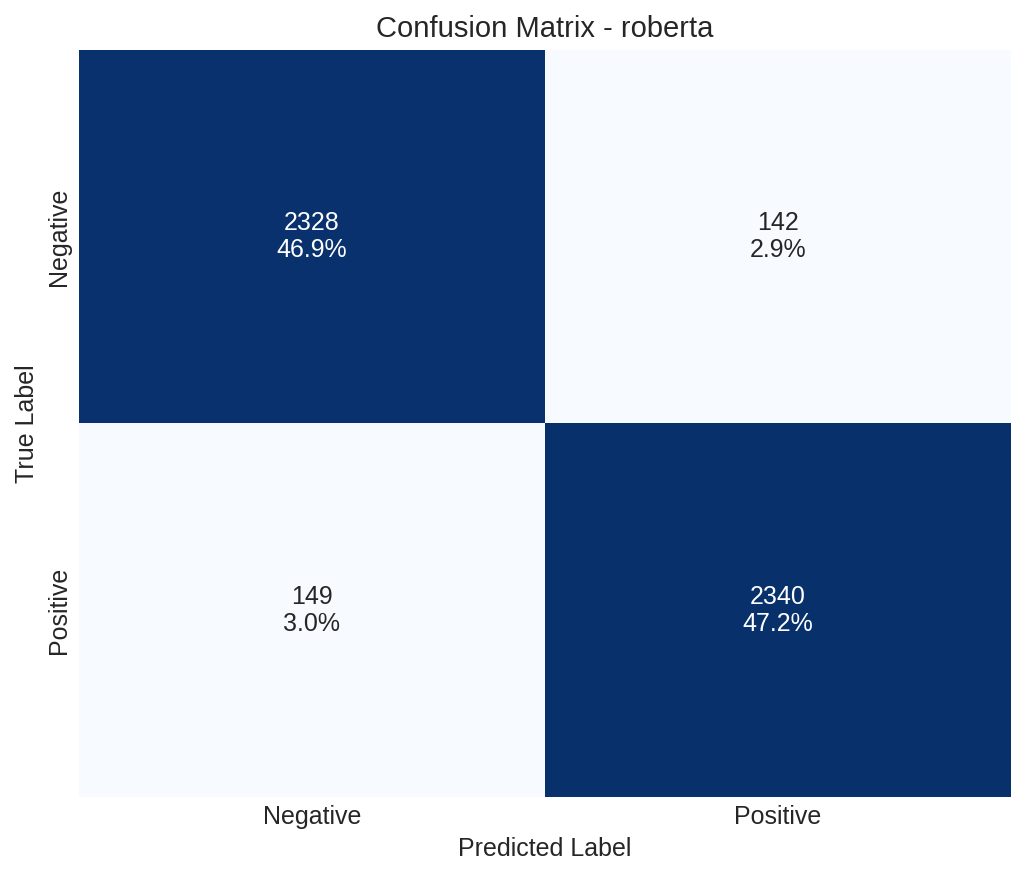

In [4]:
confusion_path = str(Path(config.FIGURES_DIR) / f"confusion_matrix_{best_model_key}.png")
visualize.plot_confusion_matrix(metrics["confusion_matrix"], best_model_key, confusion_path)
display(Image(filename=confusion_path))


**Nhận xét:**

Confusion matrix cho thấy RoBERTa có TN=2,328, FP=142, FN=149 và TP=2,340. Như vậy, mô hình dự đoán đúng 4,668 trên 4,959 review và sai 291 review, tương ứng tỷ lệ lỗi 5.87% trên toàn bộ test set.

Cụ thể, False Positive gồm 142 review có nhãn thật là `negative` nhưng bị dự đoán thành `positive`. Tỷ lệ này chiếm 5.75% trong nhóm negative thật, tức khoảng 1 trên 17 review negative bị mô hình gán nhầm thành positive. False Negative gồm 149 review có nhãn thật là `positive` nhưng bị dự đoán thành `negative`, chiếm 5.99% trong nhóm positive thật, cũng xấp xỉ 1 trên 17 review positive bị gán nhầm.

FP và FN chỉ chênh nhau 7 mẫu, cho thấy mô hình không bị thiên lệch rõ rệt về một hướng sai. Tuy nhiên, FN nhỉnh hơn FP một chút, gợi ý rằng các review positive khó có thể hơi dễ bị bỏ sót hơn so với review negative. Dù vậy, mức chênh lệch này nhỏ nên không thể xem là dấu hiệu mất cân bằng nghiêm trọng.

## 6. Đường ROC

ROC curve đánh giá năng lực phân tách hai lớp của RoBERTa trên toàn bộ dải ngưỡng quyết định. Khác với accuracy hoặc F1, vốn phụ thuộc vào một threshold cố định, AUC-ROC đo lường khả năng mô hình xếp hạng review positive cao hơn review negative dựa trên xác suất dự đoán.

Vì vậy, AUC-ROC cung cấp góc nhìn bổ sung cho các metric phân loại ở phần trước: mô hình không chỉ cần dự đoán đúng tại ngưỡng mặc định, mà còn cần tạo ra xác suất đủ phân biệt để có thể điều chỉnh threshold khi mục tiêu ứng dụng thay đổi. Biểu đồ ROC được lưu tại `results/figures/roc_curve_roberta.png`.

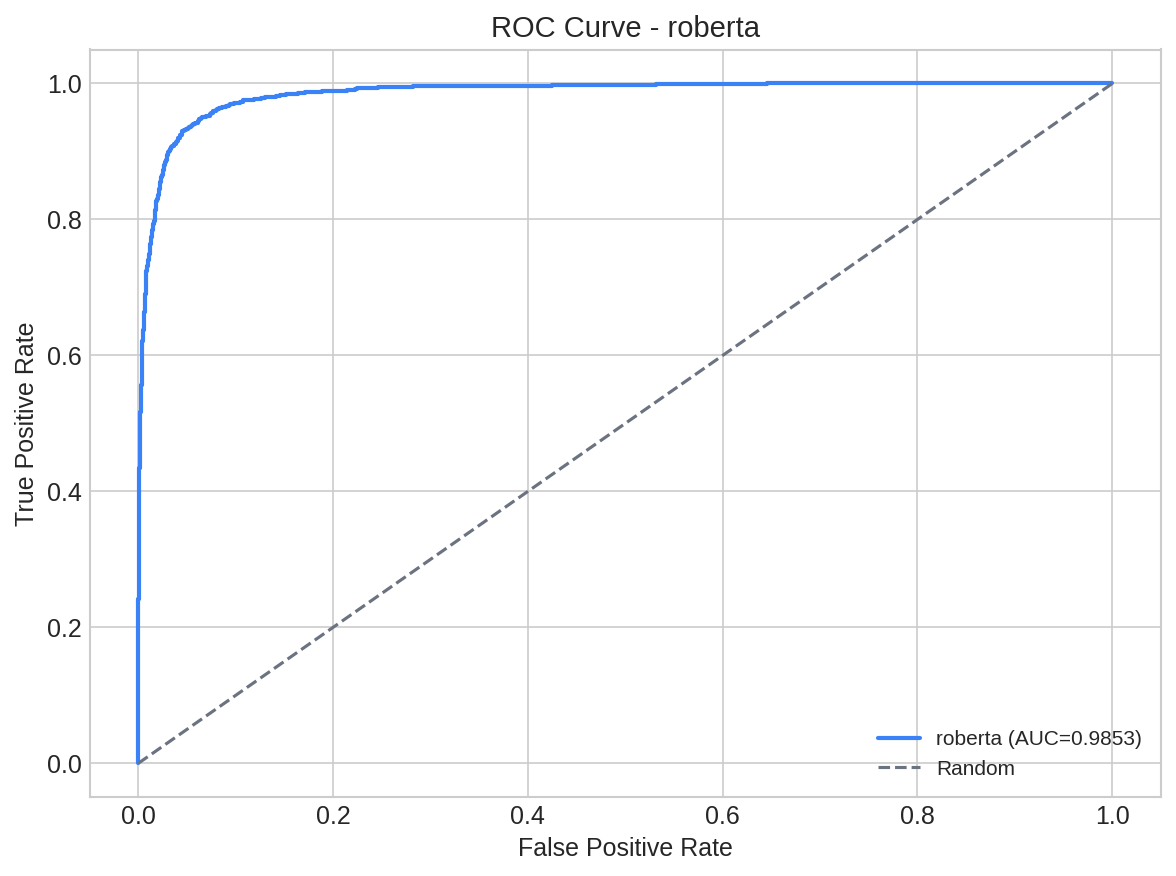

In [5]:
fpr, tpr, _ = roc_curve(true_labels, pred_probs[:, config.LABEL2ID["positive"]])
roc_path = str(Path(config.FIGURES_DIR) / f"roc_curve_{best_model_key}.png")
visualize.plot_roc_curve_single(fpr, tpr, metrics["roc_auc"], best_model_key, roc_path)
display(Image(filename=roc_path))


**Nhận xét:**

AUC đạt 0.9853, cho thấy RoBERTa có khả năng phân tách hai lớp rất mạnh. Nói cách khác, mô hình thường gán xác suất `positive` cao hơn cho review `positive` so với review `negative`.

Kết quả này đặc biệt hữu ích trong các bối cảnh cần điều chỉnh threshold theo mục tiêu đánh giá khác nhau. Ví dụ, nếu muốn giảm False Positive, có thể tăng threshold dự đoán lớp `positive`; nếu muốn giảm False Negative, có thể hạ threshold. AUC cao cho thấy việc threshold tuning có nền tảng tốt, vì mô hình đã học được thứ tự xác suất tương đối rõ ràng giữa hai lớp.

Tuy nhiên, AUC cao không đồng nghĩa mô hình không mắc lỗi. Các lỗi high-confidence ở những phần sau cho thấy vẫn có những review mà mô hình dự đoán rất chắc chắn nhưng sai do ngữ cảnh phức tạp, truncation hoặc cấu trúc cảm xúc trái chiều.

## 7. Classification report

Sau khi phân tích số lượng lỗi bằng confusion matrix, classification report được dùng để lượng hóa hiệu năng theo từng lớp. Báo cáo này cung cấp precision, recall và F1-score cho từng nhãn, qua đó cho biết mô hình không chỉ đúng bao nhiêu mẫu, mà còn đúng và sai theo cách nào đối với từng lớp sentiment.

Precision phản ánh mức độ đáng tin cậy khi mô hình dự đoán một nhãn, trong khi recall phản ánh khả năng phát hiện đầy đủ các mẫu thật sự thuộc nhãn đó. Vì vậy, classification report giúp kiểm tra liệu RoBERTa có hoạt động cân bằng trên cả `negative` và `positive` hay không.

Heatmap của classification report được lưu tại `results/figures/classification_report_roberta.png`.

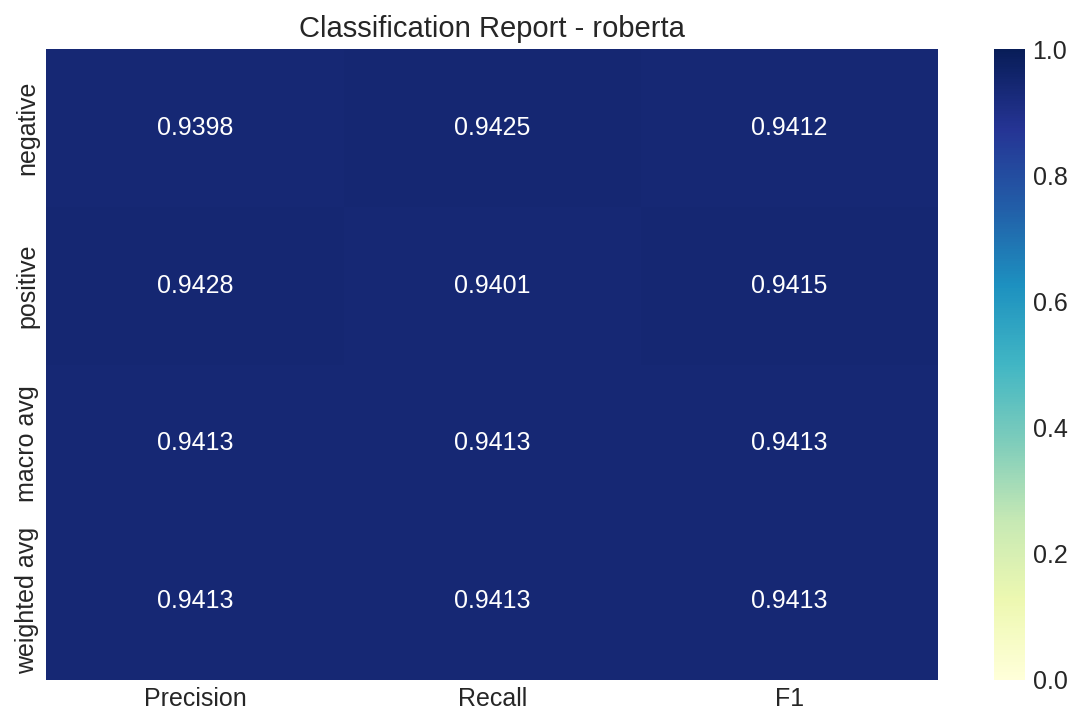

,precision,recall,f1-score,support
negative,0.939847,0.942510,0.941176,2470.000000
positive,0.942788,0.940137,0.941460,2489.000000
accuracy,0.941319,0.941319,0.941319,0.941319
macro avg,0.941317,0.941323,0.941318,4959.000000
weighted avg,0.941323,0.941319,0.941319,4959.000000


In [6]:
report_path = str(Path(config.FIGURES_DIR) / f"classification_report_{best_model_key}.png")
visualize.plot_classification_report_heatmap(metrics["classification_report"], best_model_key, report_path)
display(Image(filename=report_path))
display(pd.DataFrame(metrics["classification_report"]).T)


**Nhận xét:**

Classification report cho thấy RoBERTa hoạt động rất cân bằng trên cả hai lớp. Lớp `negative` đạt precision 93.98%, recall 94.25% và F1-score 94.12%. Lớp `positive` đạt precision 94.28%, recall 94.01% và F1-score 94.15%.

Chênh lệch giữa hai lớp rất nhỏ. Với precision, lớp `positive` cao hơn lớp `negative` khoảng 0.29 điểm phần trăm, nghĩa là khi mô hình dự đoán `positive`, dự đoán đó chính xác hơn một chút. Ngược lại, với recall, lớp `negative` cao hơn lớp `positive` khoảng 0.24 điểm phần trăm, nghĩa là mô hình phát hiện đầy đủ review `negative` tốt hơn một chút.

F1-score của hai lớp gần như tương đương: 94.12% cho `negative` và 94.15% cho `positive`. Điều này cho thấy RoBERTa không bị thiên lệch rõ rệt về một nhãn cụ thể, mà duy trì hiệu năng ổn định trên cả hai hướng sentiment.

## 8. Phân phối confidence

Phần này phân tích mức độ tự tin của RoBERTa khi đưa ra dự đoán. Confidence được định nghĩa là xác suất cao nhất trong hai lớp mà mô hình gán cho nhãn được chọn. Nói cách khác, đây là mức độ chắc chắn của mô hình đối với quyết định cuối cùng.

Việc so sánh confidence giữa dự đoán đúng và dự đoán sai giúp đánh giá liệu mô hình có xu hướng tự tin quá mức ở những trường hợp sai hay không. Phân tích này đặc biệt quan trọng vì một mô hình có accuracy cao vẫn có thể tạo ra các lỗi high-confidence, tức là những lỗi khó phát hiện nếu chỉ dựa vào xác suất dự đoán.

Biểu đồ phân phối confidence được lưu tại `results/figures/confidence_distribution_roberta.png`.

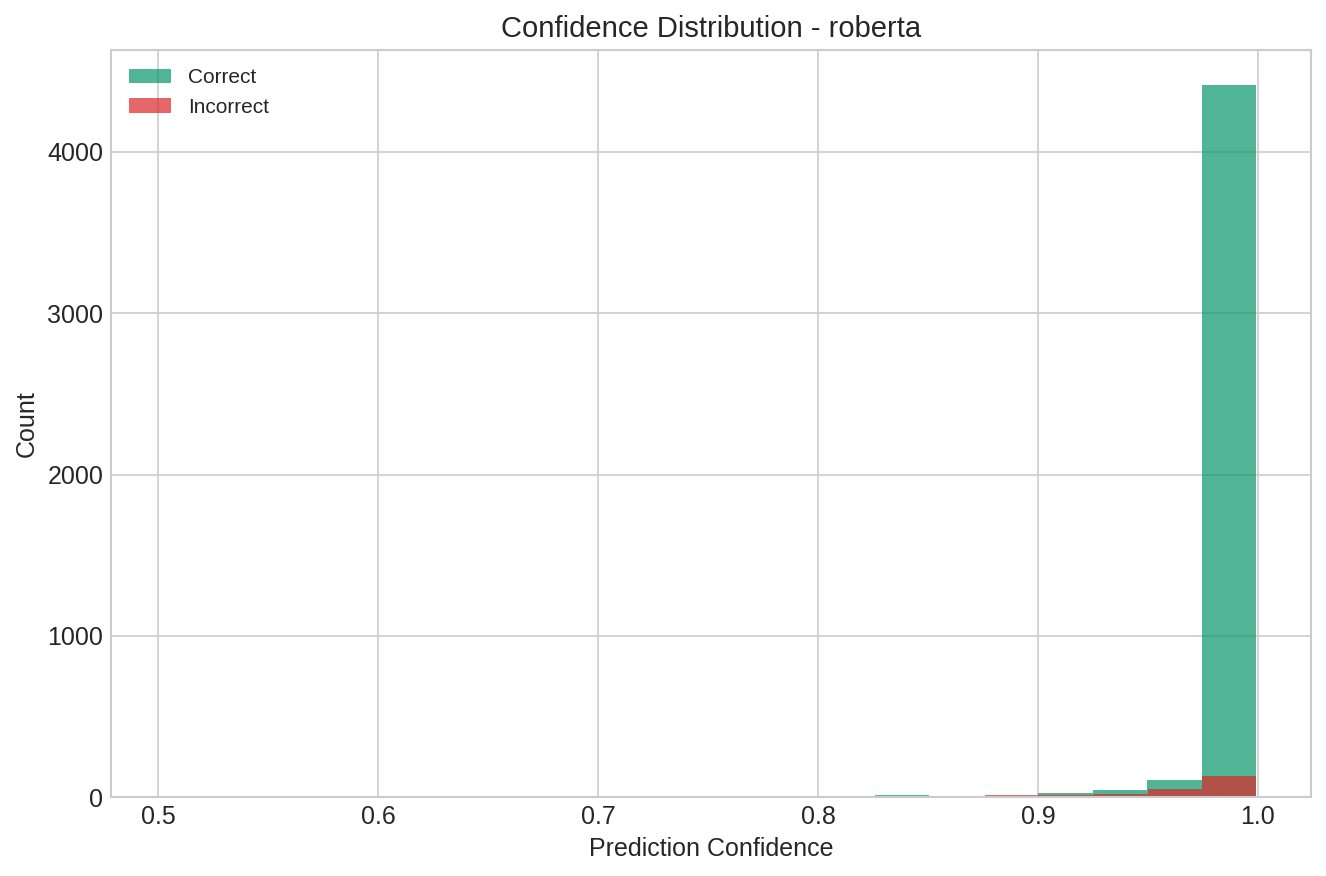

In [7]:
confidence_path = str(Path(config.FIGURES_DIR) / f"confidence_distribution_{best_model_key}.png")
visualize.plot_confidence_distribution(pred_probs, true_labels, pred_labels, best_model_key, confidence_path)
display(Image(filename=confidence_path))


**Nhận xét:**

Biểu đồ cho thấy phần lớn dự đoán của RoBERTa tập trung ở vùng confidence rất cao, đặc biệt là khoảng 0.95-1.00. Điều này phù hợp với hiệu năng tổng quát cao của mô hình trên tập test, nhưng cũng cho thấy mô hình thường đưa ra quyết định với mức xác suất rất chắc chắn.

Có 220 trên 291 lỗi có confidence lớn hơn 0.90, tương ứng 75.60% tổng số lỗi và 4.44% toàn bộ test set. Đồng thời, 4,595 trên 4,668 dự đoán đúng cũng có confidence lớn hơn 0.90, tương ứng 98.44% số dự đoán đúng. Như vậy, confidence cao là tín hiệu hữu ích vì đa số dự đoán high-confidence là đúng, nhưng nó không bảo đảm tuyệt đối rằng dự đoán chính xác.

Điểm đáng chú ý là một tỷ lệ lớn lỗi cũng nằm ở vùng high-confidence. Điều này cho thấy các lỗi còn lại không chỉ là những trường hợp mô hình phân vân, mà nhiều lỗi xuất hiện khi mô hình rất chắc chắn vào quyết định sai. Vì vậy, nếu triển khai thực tế, cần kết hợp thêm calibration, threshold tuning hoặc cơ chế kiểm tra thủ công đối với các trường hợp rủi ro cao.

## 9. Hiệu chuẩn confidence

Calibration đánh giá mức độ phù hợp giữa xác suất dự đoán và độ chính xác thực tế. Một mô hình được hiệu chuẩn tốt nếu nhóm dự đoán có confidence khoảng 90% cũng đúng xấp xỉ 90% trong thực tế. Ngược lại, nếu mô hình thường đưa ra confidence rất cao nhưng accuracy thực tế thấp hơn đáng kể, mô hình đang có xu hướng overconfident.

Trong notebook này, Expected Calibration Error (ECE) được dùng để tóm tắt mức độ sai lệch giữa confidence và accuracy. ECE được tính bằng trung bình có trọng số của khoảng cách tuyệt đối giữa confidence trung bình và accuracy thực tế trong từng confidence bin. Giá trị ECE càng thấp thì xác suất dự đoán càng phản ánh tốt độ tin cậy thực tế.

Reliability diagram được lưu tại `results/figures/calibration_curve_roberta.png`.

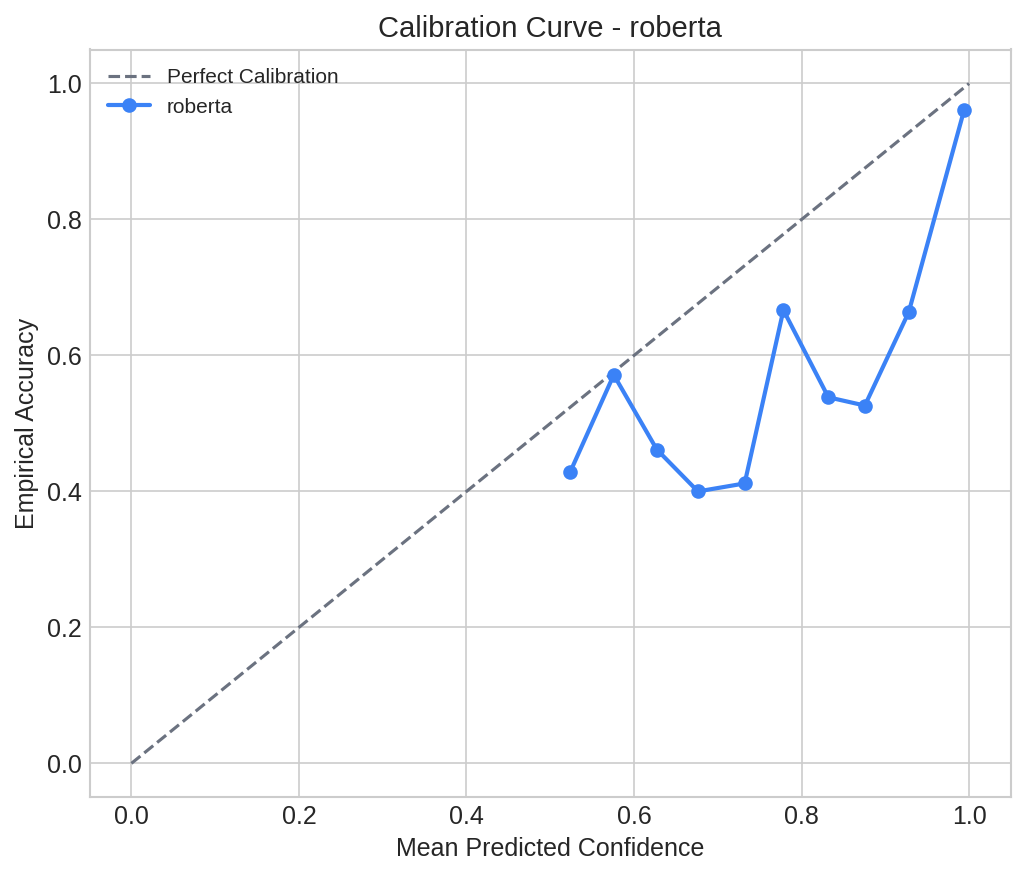

,bin_left,bin_right,accuracy,confidence,count
0,0.50,0.55,0.428571,0.523794,14
1,0.55,0.60,0.571429,0.575825,14
2,0.60,0.65,0.461538,0.627280,13
3,0.65,0.70,0.400000,0.676303,10
4,0.70,0.75,0.411765,0.732049,17
5,0.75,0.80,0.666667,0.778319,12
6,0.80,0.85,0.538462,0.831989,26
7,0.85,0.90,0.526316,0.875542,38
8,0.90,0.95,0.663717,0.927929,113
9,0.95,1.00,0.961293,0.994132,4702


Expected calibration error: 0.0440


In [8]:
calibration = evaluate.confidence_calibration(true_labels, pred_labels, pred_probs, n_bins=10)
calibration_path = str(Path(config.FIGURES_DIR) / f"calibration_curve_{best_model_key}.png")
visualize.plot_calibration_curve(calibration, best_model_key, calibration_path)
display(Image(filename=calibration_path))
display(pd.DataFrame({"bin_left": calibration["bin_edges"][:-1], "bin_right": calibration["bin_edges"][1:], "accuracy": calibration["bin_accuracies"], "confidence": calibration["bin_confidences"], "count": calibration["bin_counts"]}))
print(f"Expected calibration error: {calibration['expected_calibration_error']:.4f}")


**Nhận xét:**

Reliability diagram cho thấy RoBERTa có xu hướng nằm dưới đường perfect calibration ở nhiều khoảng confidence, đặc biệt trong vùng confidence cao. Điều này nghĩa là confidence trung bình của mô hình thường cao hơn accuracy thực tế, hay nói cách khác mô hình có xu hướng overconfident.

Expected Calibration Error của RoBERTa là 0.0440, tương ứng sai lệch calibration trung bình khoảng 4.4 điểm phần trăm. Đây không phải là mức sai lệch quá lớn, nhưng vẫn đáng lưu ý vì phần lớn dự đoán tập trung ở vùng confidence rất cao. Cụ thể, bin 0.95-1.00 là nhóm lớn nhất với 4,702 dự đoán, chiếm khoảng 94.8% toàn bộ test set. Trong nhóm này, confidence trung bình là 99.41%, trong khi accuracy thực tế là 96.13%. Khoảng cách 3.28 điểm phần trăm cho thấy mô hình dự đoán rất chắc chắn, nhưng mức chắc chắn này vẫn cao hơn độ chính xác thực tế.

Các bin confidence thấp hơn có số lượng mẫu nhỏ, chẳng hạn bin 0.50-0.55 chỉ có 14 mẫu và bin 0.65-0.70 chỉ có 10 mẫu. Vì vậy, không nên diễn giải quá mạnh từng bin riêng lẻ ở vùng confidence thấp. Tổng thể, RoBERTa có calibration chấp nhận được cho mục tiêu phân tích, nhưng nếu xác suất dự đoán được dùng làm tiêu chí ra quyết định trong triển khai thực tế, nên cân nhắc temperature scaling hoặc threshold tuning trên validation set riêng.

## 10. Phân tích lỗi

Các metric tổng hợp cho biết mô hình đạt hiệu năng cao, nhưng chưa giải thích mô hình sai trong những tình huống nào. Vì vậy, phần này tập trung vào các dự đoán sai, chia theo hai nhóm chính: False Positive và False Negative.

False Positive là các review có nhãn thật là `negative` nhưng bị dự đoán thành `positive`; False Negative là các review có nhãn thật là `positive` nhưng bị dự đoán thành `negative`. Việc phân tích hai nhóm lỗi này giúp nhận diện các giới hạn còn lại của RoBERTa, đặc biệt là những review có ngôn ngữ bề mặt trái với nhãn tổng thể, có cấu trúc tương phản, chứa nhiều đoạn đánh giá pha trộn hoặc bị mất thông tin do truncation.

In [9]:
errors = evaluate.error_analysis(test_texts, true_labels, pred_labels, pred_probs)
error_overview = errors["error_type"].value_counts().rename_axis("error_type").reset_index(name="count") if not errors.empty else pd.DataFrame(columns=["error_type", "count"])
error_overview["percentage"] = error_overview["count"] / len(test_texts) if not error_overview.empty else []
print(f"Total errors: {len(errors)} out of {len(test_texts)}")
display(error_overview)


Total errors: 291 out of 4959


,error_type,count,percentage
0,False Negative,149,0.030046
1,False Positive,142,0.028635


**Nhận xét:**

RoBERTa có 291 lỗi trên test set, tương ứng 5.87% tổng số 4,959 review. Trong đó, False Negative chiếm 149 mẫu, tương ứng 3.00% toàn bộ test set; False Positive chiếm 142 mẫu, tương ứng 2.86%.

Chênh lệch giữa hai nhóm lỗi chỉ là 7 mẫu, cho thấy mô hình không lệch mạnh về một loại lỗi cụ thể. Tuy nhiên, False Negative nhỉnh hơn một chút, nghĩa là RoBERTa hơi có xu hướng bỏ sót một số review `positive` hơn là gán nhầm review `negative` thành `positive`.

So với baseline TF-IDF + Logistic Regression, số lỗi giảm từ 453 xuống 291, tức giảm 162 lỗi. Điều này cho thấy RoBERTa cải thiện đáng kể khả năng phân loại tổng quát, nhưng vẫn còn một nhóm lỗi khó cần được phân tích sâu hơn ở các phần tiếp theo.

### 10.1. False Positive có confidence cao

False Positive là các review có nhãn thật là `negative` nhưng bị mô hình dự đoán thành `positive`. Nhóm lỗi này cho biết mô hình có thể bị đánh lừa bởi các tín hiệu tích cực bề mặt trong một review có đánh giá tổng thể tiêu cực.

Phần này hiển thị các False Positive có confidence cao nhất để phân tích những trường hợp mô hình sai nhưng vẫn rất chắc chắn.

In [10]:
false_positives = errors[errors["error_type"] == "False Positive"].head(15) if not errors.empty else pd.DataFrame()
if false_positives.empty:
    print("No false positives found.")
else:
    display(false_positives[["text", "confidence", "word_count", "was_truncated"]])


,text,confidence,word_count,was_truncated
16,'Ernest Saves Christmas' is comedian Ernest's ...,0.995489,140,False
19,It is enjoyable and fast-paced. There is no wa...,0.995310,145,False
21,"Sorry to disagree with you, but I found the DK...",0.994948,136,False
25,I was unsure whether or not Andy Sidaris could...,0.994689,246,False
27,I'm not going to waste my time writing an essa...,0.994372,177,False
29,When i finally had the opportunity to watch Zo...,0.994185,350,True
31,The movie was a pleasure to watch if you are a...,0.993984,114,False
32,I saw this film in its entirety in the 1960s &...,0.993964,198,False
34,Occasionally one is served a new entrée from f...,0.993793,233,False
35,Richard Tyler is a little boy who is scared of...,0.993067,105,False


**Nhận xét:**

Bảng False Positive cho thấy nhiều review `negative` bị RoBERTa dự đoán thành `positive` với confidence rất cao, phần lớn trên 99%. Một số ví dụ nổi bật gồm review về `'Ernest Saves Christmas'` với confidence 99.55%, review bắt đầu bằng `It is enjoyable and fast-paced...` với confidence 99.53%, và review `Sorry to disagree with you...` với confidence 99.49%.

Các lỗi này thường xuất hiện ở những review chứa tín hiệu tích cực bề mặt hoặc mô tả có vẻ thuận lợi, chẳng hạn như `Christmas`, `enjoyable`, `fast-paced`, `pleasure to watch`, hoặc các đoạn giới thiệu nội dung mang sắc thái giải trí. Tuy nhiên, nhãn thật của các review này là `negative`, cho thấy đánh giá tổng thể của người viết không trùng với những tín hiệu tích cực cục bộ mà mô hình có thể đang ưu tiên.

Một điểm đáng chú ý là một số False Positive có `was_truncated=True`, chẳng hạn các review có độ dài 350, 484 hoặc 781 từ. Điều này gợi ý rằng với các review dài, mô hình có thể không quan sát đầy đủ phần văn bản chứa đánh giá cuối cùng hoặc các tín hiệu tiêu cực quan trọng. Vì vậy, False Positive high-confidence có thể đến từ sự kết hợp giữa tín hiệu tích cực cục bộ, cấu trúc lập luận trái chiều và giới hạn độ dài đầu vào.

### 10.2. False Negative có confidence cao

False Negative là các review có nhãn thật là `positive` nhưng bị mô hình dự đoán thành `negative`. Nhóm lỗi này cho biết mô hình có thể bị ảnh hưởng bởi các tín hiệu tiêu cực bề mặt trong những review mà đánh giá tổng thể vẫn là tích cực.

Phần này hiển thị các False Negative có confidence cao nhất để phân tích những trường hợp mô hình bỏ sót review `positive` nhưng vẫn rất chắc chắn với dự đoán `negative`.

In [11]:
false_negatives = errors[errors["error_type"] == "False Negative"].head(15) if not errors.empty else pd.DataFrame()
if false_negatives.empty:
    print("No false negatives found.")
else:
    display(false_negatives[["text", "confidence", "word_count", "was_truncated"]])


,text,confidence,word_count,was_truncated
0,This was one of the worst Columbo episodes tha...,0.999292,136,False
1,**SPOILERS AHEAD** It is really unfortunate th...,0.999277,347,True
2,Thanks to this fungal film I do NOT want my Ma...,0.999222,43,False
3,THE MELTING MAN...a tragic victim of the space...,0.999200,379,True
4,"Over the years, we've seen a lot of prepostero...",0.999196,460,True
5,"Jack Frost 2, is probably the most cheesiest m...",0.999059,343,True
6,I found this film to be the usual French slap ...,0.998983,164,False
7,We have to remember that the 50's were practic...,0.998954,357,True
8,Hrm-I think that line was from the old movie p...,0.998879,241,False
9,There are many police dramas doing the rounds....,0.997840,287,True


**Nhận xét:**

Bảng False Negative cho thấy nhiều review `positive` bị RoBERTa dự đoán thành `negative` với confidence rất cao, đa số trên 99%. Một số ví dụ nổi bật gồm review bắt đầu bằng `This was one of the worst Columbo episodes...` với confidence 99.93%, review `**SPOILERS AHEAD**...` với confidence 99.93%, và review `Thanks to this fungal film...` với confidence 99.92%.

Các trường hợp này thường chứa nhiều tín hiệu tiêu cực bề mặt như `worst`, `unfortunate`, `NOT want`, hoặc các đoạn mô tả nội dung gây khó chịu. Tuy nhiên, nhãn thật lại là `positive`, cho thấy người viết có thể đang dùng ngôn ngữ tiêu cực để mô tả nội dung phim, thể loại, cảm giác khi xem hoặc một phần cụ thể của tác phẩm, chứ không nhất thiết phủ định giá trị tổng thể của bộ phim.

Một điểm đáng chú ý là nhiều False Negative có `was_truncated=True`, đặc biệt ở các review dài trên 300 từ. Điều này gợi ý rằng mô hình có thể chưa quan sát đầy đủ phần kết luận tích cực hoặc các tín hiệu đảo chiều quan điểm nằm ở cuối review. Nhóm lỗi này cho thấy sentiment analysis trên IMDb không chỉ đòi hỏi nhận diện từ khóa cảm xúc, mà còn cần phân biệt giữa ngôn ngữ mô tả nội dung và ngôn ngữ đánh giá chất lượng.

### 10.3. Tóm tắt mẫu lỗi

Để có cái nhìn tổng quát hơn về các lỗi còn lại, phần này dùng một số heuristic đơn giản để gán lỗi vào các nhóm như `Contrast`, `Negation`, `Positive words in error`, `Negative words in error` và `Other`.

Cách phân loại này không nhằm thay thế phân tích thủ công từng review, vì một lỗi có thể xuất phát từ nhiều nguyên nhân cùng lúc. Tuy vậy, heuristic giúp nhận diện nhanh những mẫu ngôn ngữ thường xuất hiện trong các dự đoán sai, đặc biệt là cấu trúc tương phản, phủ định hoặc sự xuất hiện của từ khóa sentiment trái với nhãn tổng thể.

In [12]:
def assign_error_category(text):
    lower_text = str(text).lower()
    if any(term in lower_text for term in ["not bad", "not terrible", "not awful", "not good"]):
        return "Negation"
    if " but " in lower_text or " however " in lower_text:
        return "Contrast"
    if any(term in lower_text for term in ["masterpiece", "brilliant", "amazing", "wonderful"]):
        return "Positive words in error"
    if any(term in lower_text for term in ["waste", "boring", "awful", "terrible"]):
        return "Negative words in error"
    return "Other"

if errors.empty:
    category_summary = pd.DataFrame(columns=["category", "count", "percentage", "example"])
else:
    categorized_errors = errors.copy()
    categorized_errors["category"] = categorized_errors["text"].apply(assign_error_category)
    category_summary = categorized_errors.groupby("category").agg(count=("category", "size"), example=("text", "first")).reset_index()
    category_summary["percentage"] = category_summary["count"] / len(errors)

display(category_summary.sort_values("count", ascending=False))


,category,count,example,percentage
0,Contrast,225,This was one of the worst Columbo episodes tha...,0.773196
3,Other,49,Thanks to this fungal film I do NOT want my Ma...,0.168385
2,Negative words in error,7,I saw this film in its entirety in the 1960s &...,0.024055
4,Positive words in error,6,'Opera' (1987) Director: Dario Argento (Deep R...,0.020619
1,Negation,4,Surprisingly not terrible and well animated fo...,0.013746


**Nhận xét:**

Heuristic phân loại lỗi cho thấy nhóm `Contrast` chiếm tỷ lệ lớn nhất với 225 trên 291 lỗi, tương ứng 77.32%. Các nhóm còn lại có quy mô nhỏ hơn nhiều: `Other` gồm 49 lỗi (16.84%), `Negative words in error` gồm 7 lỗi (2.41%), `Positive words in error` gồm 6 lỗi (2.06%) và `Negation` gồm 4 lỗi (1.37%).

Kết quả này cho thấy phần lớn lỗi không xuất phát từ phủ định đơn giản hay một vài từ khóa sentiment riêng lẻ, mà liên quan nhiều hơn đến cấu trúc tương phản và chuyển hướng cảm xúc trong review. Các mẫu có `but` hoặc `however` thường chứa hai vế đánh giá trái chiều; do đó, mô hình phải xác định vế nào mang ý nghĩa kết luận mạnh hơn đối với sentiment tổng thể.

Tuy nhiên, cần diễn giải kết quả này như một phân tích định tính dựa trên heuristic. Một review có thể đồng thời chứa cấu trúc tương phản, từ khóa tích cực, từ khóa tiêu cực và cả truncation. Vì vậy, nhãn `Contrast` không nhất thiết là nguyên nhân duy nhất gây lỗi, mà là dấu hiệu cho thấy review có cấu trúc ngôn ngữ phức tạp hơn.

Kết quả này cũng liên hệ trực tiếp với các phần phân tích phía sau. Nếu nhiều lỗi nằm ở các review dài hoặc bị truncation, mô hình có thể không quan sát đầy đủ phần kết luận hoặc không gán đủ trọng số cho tín hiệu sentiment xuất hiện muộn trong văn bản. Do đó, một hướng kiểm tra hợp lý là thử `MAX_LENGTH=512` hoặc các chiến lược xử lý long document như sliding window để xem lỗi thuộc nhóm `Contrast` có giảm hay không.

## 11. Phân tích tác động của truncation

Với `MAX_LENGTH=256`, các review dài hơn giới hạn token sẽ bị cắt bớt trước khi đưa vào mô hình. Điều này có thể làm mất các phần quan trọng của review, đặc biệt khi kết luận sentiment hoặc tín hiệu đảo chiều quan điểm xuất hiện ở cuối văn bản.

Phần này so sánh hiệu năng giữa hai nhóm: các review nằm trong giới hạn token và các review bị truncation. Nếu nhóm bị truncation có accuracy hoặc F1 thấp hơn rõ rệt, điều đó cho thấy giới hạn độ dài đầu vào là một bottleneck đáng chú ý của mô hình hiện tại.

Cần lưu ý rằng phân tích này không chứng minh truncation là nguyên nhân duy nhất gây lỗi, vì review dài thường cũng có cấu trúc lập luận phức tạp hơn. Tuy vậy, sự khác biệt giữa hai nhóm sẽ giúp đánh giá mức độ ảnh hưởng của việc cắt chuỗi đến hiệu năng phân loại.

In [13]:
truncation_results = evaluate.truncation_analysis(test_texts, true_labels, pred_labels, best_tokenizer, config.MAX_LENGTH)
truncation_table = pd.DataFrame(
    [
        {
            "group": "within_limit",
            "count": truncation_results["within_limit_count"],
            "accuracy": truncation_results["within_limit_accuracy"],
            "f1": truncation_results["within_limit_f1"],
        },
        {
            "group": "truncated",
            "count": truncation_results["truncated_count"],
            "accuracy": truncation_results["truncated_accuracy"],
            "f1": truncation_results["truncated_f1"],
        },
        {
            "group": "gap",
            "count": None,
            "accuracy": truncation_results["accuracy_gap"],
            "f1": None,
        },
    ]
)
display(truncation_table)


Token lengths:   0%|          | 0/4959 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (666 > 512). Running this sequence through the model will result in indexing errors


,group,count,accuracy,f1
0,within_limit,3022.0,0.954004,0.954004
1,truncated,1937.0,0.921528,0.921521
2,gap,NaN,0.032476,NaN


**Nhận xét:**

Kết quả cho thấy 3,022 review không bị cắt, chiếm khoảng 60.9% test set, trong khi 1,937 review bị truncation, chiếm khoảng 39.1%. Nhóm không bị cắt đạt 95.40% accuracy và 95.40% F1, còn nhóm bị truncation chỉ đạt 92.15% accuracy và 92.15% F1.

Khoảng cách accuracy giữa hai nhóm là 3.25 điểm phần trăm. Tính theo số lỗi, nhóm không bị cắt có 135 lỗi trên 3,022 mẫu, tương ứng 4.47%; nhóm bị cắt có 156 lỗi trên 1,937 mẫu, tương ứng 8.05%. Như vậy, tỷ lệ lỗi của nhóm bị truncation cao hơn khoảng 1.8 lần so với nhóm không bị truncation.

Kết quả này cho thấy truncation là một nguồn suy giảm hiệu năng đáng kể. Một phần thông tin sentiment quan trọng có thể nằm ngoài 256 token đầu tiên, đặc biệt trong các review dài có nhiều lập luận, chuyển ý hoặc kết luận nằm ở cuối văn bản. Vì vậy, một hướng cải thiện hợp lý là thử `MAX_LENGTH=512` hoặc các chiến lược xử lý văn bản dài như sliding window, hierarchical encoding hoặc kết hợp phần đầu và phần cuối review.

## 12. Hiệu năng theo độ dài review

Ngoài tác động của truncation theo token, notebook cũng đánh giá hiệu năng theo độ dài review tính bằng số từ. Các review được chia thành ba nhóm: `short` dưới 100 từ, `medium` từ 100 đến dưới 300 từ và `long` từ 300 từ trở lên.

Cách phân tích này giúp kiểm tra liệu RoBERTa có hoạt động ổn định trên mọi độ dài văn bản hay không. Review ngắn thường chứa ít lập luận và ít khả năng bị cắt chuỗi, trong khi review dài có thể chứa nhiều ý kiến trái chiều, nhiều đoạn chuyển hướng cảm xúc và nguy cơ bị truncation cao hơn.

Phần này tính accuracy và F1 macro cho từng nhóm độ dài, sau đó trực quan hóa accuracy theo nhóm để quan sát xu hướng suy giảm hiệu năng nếu có.

/tmp/ipykernel_355/1977470021.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  length_summary = length_df.groupby("length_group", observed=False).apply(


,length_group,count,accuracy,f1_macro
0,short,651.0,0.963134,0.962849
1,medium,3206.0,0.951653,0.951612
2,long,1102.0,0.898367,0.898173


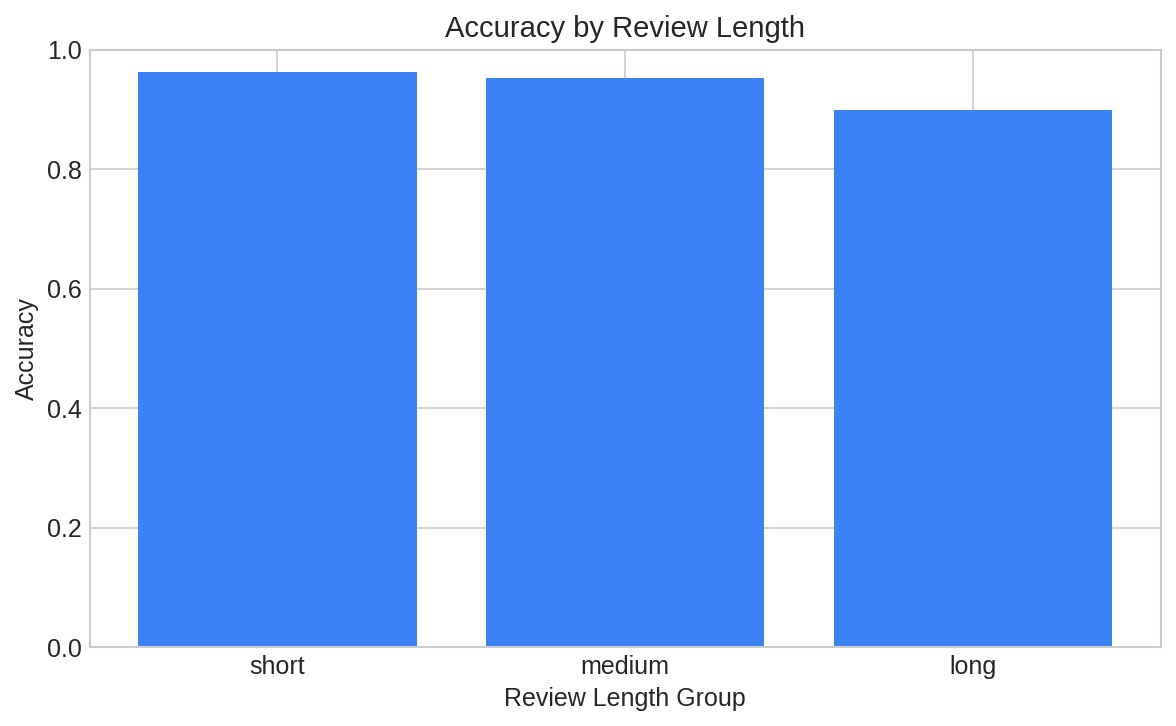

In [14]:
length_df = pd.DataFrame(
    {
        "text": test_texts,
        "word_count": [len(text.split()) for text in test_texts],
        "true_label": true_labels,
        "pred_label": pred_labels,
    }
)
length_df["length_group"] = pd.cut(
    length_df["word_count"],
    bins=[0, 100, 300, float("inf")],
    labels=["short", "medium", "long"],
    right=False,
)
length_summary = length_df.groupby("length_group", observed=False).apply(
    lambda frame: pd.Series(
        {
            "count": len(frame),
            "accuracy": accuracy_score(frame["true_label"], frame["pred_label"]),
            "f1_macro": f1_score(frame["true_label"], frame["pred_label"], average="macro", zero_division=0),
        }
    )
).reset_index()
display(length_summary)

length_path = Path(config.FIGURES_DIR) / f"length_performance_{best_model_key}.png"
plt.figure(figsize=(8, 5))
plt.bar(length_summary["length_group"].astype(str), length_summary["accuracy"], color="#3b82f6")
plt.ylim(0, 1)
plt.xlabel("Review Length Group")
plt.ylabel("Accuracy")
plt.title("Accuracy by Review Length")
plt.tight_layout()
plt.savefig(length_path, dpi=config.FIGURE_DPI, bbox_inches="tight")
plt.close()
display(Image(filename=str(length_path)))


**Nhận xét:**

Kết quả cho thấy hiệu năng của RoBERTa giảm rõ rệt khi độ dài review tăng. Nhóm `short` có 651 review, đạt 96.31% accuracy và 96.28% F1 macro. Nhóm `medium` có 3,206 review, đạt 95.17% accuracy và 95.16% F1 macro. Trong khi đó, nhóm `long` có 1,102 review, chỉ đạt 89.84% accuracy và 89.82% F1 macro.

Tính theo số lỗi, nhóm `short` có 22 lỗi trên 651 mẫu, tương ứng 3.38%; nhóm `medium` có 154 lỗi trên 3,206 mẫu, tương ứng 4.81%; nhóm `long` có 115 lỗi trên 1,102 mẫu, tương ứng 10.44%. Như vậy, tỷ lệ lỗi của nhóm `long` cao hơn khoảng 3.1 lần so với nhóm `short`.

Xu hướng này phù hợp với phân tích truncation ở phần trước. Review dài không chỉ dễ bị cắt chuỗi hơn, mà còn thường chứa nhiều lập luận, nhiều tín hiệu trái chiều và phụ thuộc dài giữa các đoạn. Do đó, mô hình có thể gặp khó khăn trong việc xác định sentiment tổng thể nếu thông tin quan trọng nằm xa phần đầu hoặc bị phân tán trong văn bản.

Kết quả này cho thấy độ dài review là một bottleneck quan trọng của cấu hình hiện tại. Một hướng cải thiện hợp lý là thử `MAX_LENGTH=512`, sliding window, hierarchical encoding hoặc chiến lược kết hợp phần đầu và phần cuối review để mô hình quan sát được nhiều thông tin hơn trong các review dài.

## 13. Kết luận

Notebook này đánh giá chi tiết RoBERTa trên tập test độc lập và cho thấy đây là mô hình tốt nhất của dự án. RoBERTa đạt 94.13% accuracy, 94.13% F1 macro và AUC 0.9853. Mô hình dự đoán đúng 4,668 trên 4,959 review và sai 291 review, gồm 142 False Positive và 149 False Negative.

So với baseline TF-IDF + Logistic Regression, RoBERTa tăng accuracy từ 90.87% lên 94.13%, tức cải thiện 3.27 điểm phần trăm. Số lỗi giảm từ 453 xuống 291, tương đương giảm 162 lỗi. Kết quả này cho thấy biểu diễn ngữ cảnh hóa của Transformer giúp mô hình xử lý sentiment tốt hơn so với đặc trưng từ vựng bề mặt.

Điểm mạnh chính của RoBERTa là hiệu năng cao và cân bằng giữa hai lớp. Classification report cho thấy F1 của lớp `negative` và `positive` đều xấp xỉ 94.1%, trong khi confusion matrix cho thấy số False Positive và False Negative gần tương đương. AUC 0.9853 cũng cho thấy mô hình có khả năng phân tách xác suất rất tốt, tạo nền tảng thuận lợi nếu cần điều chỉnh threshold theo mục tiêu ứng dụng.

Tuy nhiên, các phân tích sâu hơn cũng chỉ ra một số giới hạn quan trọng. Thứ nhất, nhiều lỗi vẫn là lỗi high-confidence: 220 trên 291 lỗi có confidence lớn hơn 0.90, tương ứng 75.60% tổng số lỗi. Điều này cho thấy confidence cao không thể được xem là bảo đảm tuyệt đối cho dự đoán đúng. Thứ hai, heuristic error analysis cho thấy 77.32% lỗi thuộc nhóm `Contrast`, gợi ý rằng các review có cấu trúc tương phản hoặc chuyển hướng cảm xúc vẫn là thách thức lớn. Thứ ba, truncation và độ dài review ảnh hưởng rõ rệt đến hiệu năng: nhóm review bị cắt thấp hơn nhóm không bị cắt 3.25 điểm phần trăm accuracy, trong khi nhóm `long` thấp hơn nhóm `short` 6.48 điểm phần trăm.

Từ các kết quả này, các hướng cải thiện hợp lý gồm hiệu chuẩn xác suất bằng `temperature scaling`, điều chỉnh threshold trên validation set riêng, thử `MAX_LENGTH=512`, hoặc áp dụng các chiến lược xử lý văn bản dài như `sliding window`, `hierarchical encoding` hay kết hợp phần đầu và phần cuối review. Những hướng này đặc biệt phù hợp nếu mục tiêu là giảm lỗi ở review dài, review có cấu trúc tương phản hoặc các trường hợp mô hình dự đoán sai với confidence cao.